In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("../Online Retail.csv")


In [3]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
# Check Null Values 
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
# Remove Null Description
df = df.dropna(subset=['Description'])

In [7]:
# Remove Rows with Null CustomerID

df = df.dropna(subset=['CustomerID'])

In [8]:
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [9]:
# Check total duplicate rows
duplicate_count = df.duplicated().sum()
print(duplicate_count)

5225


In [10]:
# Remove Duplicate Rows
df = df.drop_duplicates()


In [11]:
#Negative Quantities (filtering)
df = df[df['Quantity'] > 0]

In [12]:
#Zero or Negative UnitPrice  (filtering)
df = df[df['UnitPrice'] > 0]

In [13]:
# Convert CustomerID to Integer
df['CustomerID'] = df['CustomerID'].astype(int)

In [14]:
# Create TotalPrice Column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [15]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  object 
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  int64  
 7   Country      392692 non-null  object 
 8   TotalPrice   392692 non-null  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 30.0+ MB
None
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64


In [16]:
# Remove cancellation invoices  (filtering)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [17]:
# Convert InvoiceDate to Proper Datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [18]:
# Create RFM Table
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [19]:
rfm.shape[0]

4338

In [20]:
df['CustomerID'].nunique()

4338

In [21]:
print(rfm.describe())

           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000


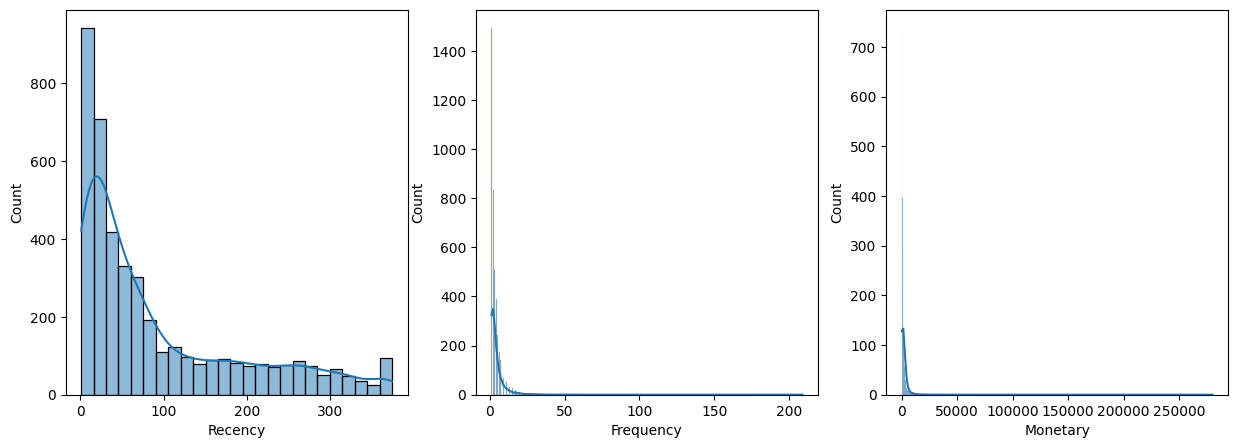

In [22]:
# Distribution Plots
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(rfm['Recency'], kde=True)

plt.subplot(1,3,2)
sns.histplot(rfm['Frequency'], kde=True)

plt.subplot(1,3,3)
sns.histplot(rfm['Monetary'], kde=True)

plt.show()

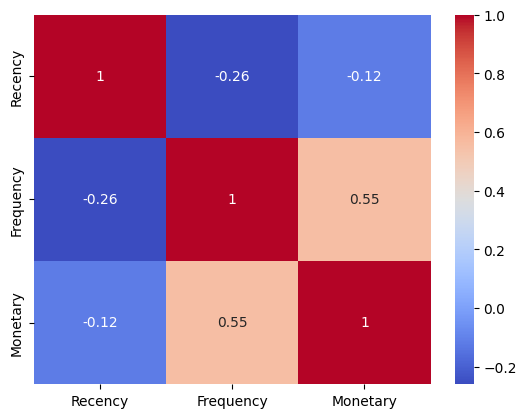

In [23]:
# Correlation Heatmap

sns.heatmap(rfm.corr(), annot=True, cmap='coolwarm')
plt.show()

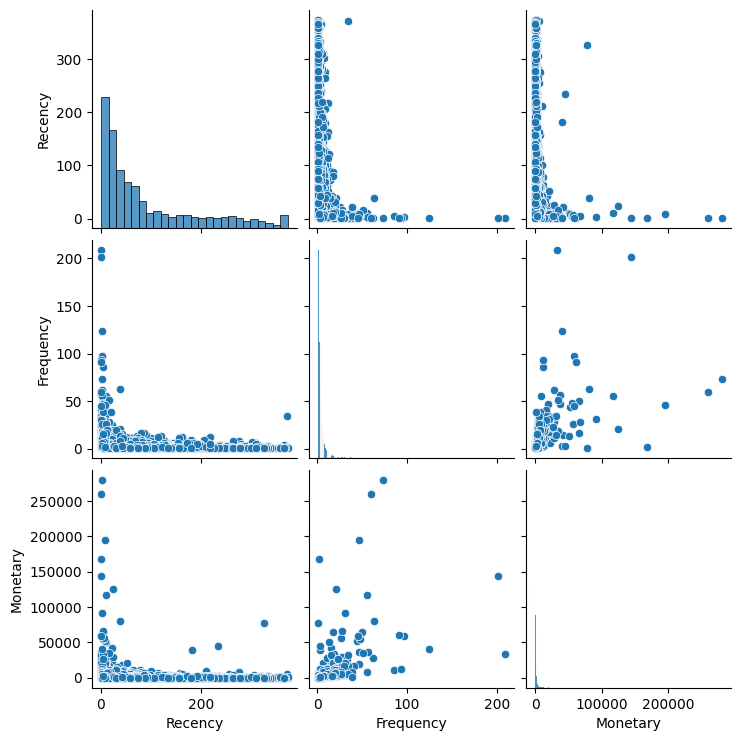

In [24]:
# Pairplot

sns.pairplot(rfm)
plt.show()

In [25]:
# Handle Skewness
import numpy as np

rfm['Recency'] = np.log1p(rfm['Recency'])
rfm['Frequency'] = np.log1p(rfm['Frequency'])
rfm['Monetary'] = np.log1p(rfm['Monetary'])

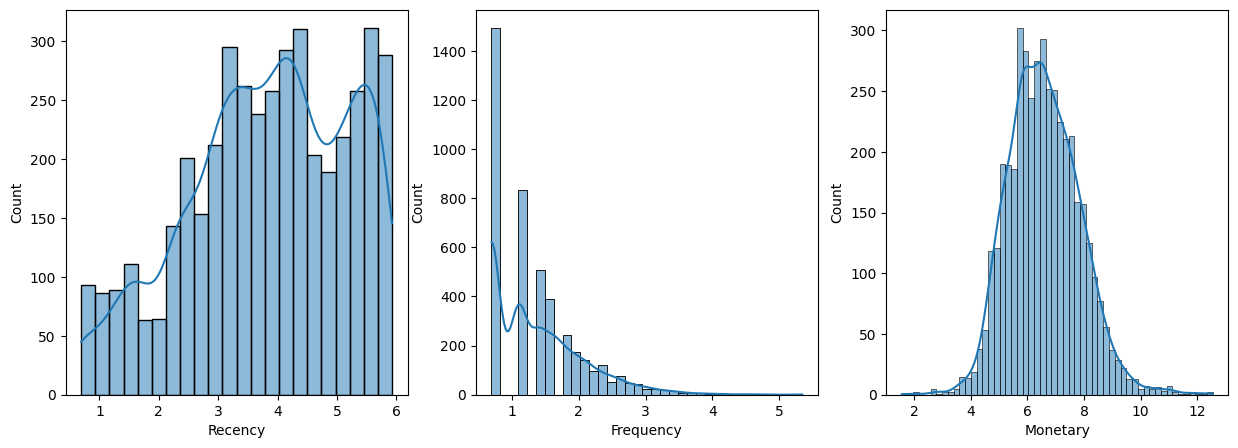

In [26]:
# Distribution Plots
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(rfm['Recency'], kde=True)

plt.subplot(1,3,2)
sns.histplot(rfm['Frequency'], kde=True)

plt.subplot(1,3,3)
sns.histplot(rfm['Monetary'], kde=True)

plt.show()

In [27]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [28]:
rfm

,Recency,Frequency,Monetary
CustomerID,,,
12346,5.789960,0.693147,11.253955
12347,1.098612,2.079442,8.368925
12348,4.330733,1.609438,7.494564
12349,2.995732,0.693147,7.472245
12350,5.739793,0.693147,5.815324
...,...,...,...
18280,5.631212,0.693147,5.201806
18281,5.204007,0.693147,4.404522
18282,2.197225,1.098612,5.187665


In [29]:
print(rfm.shape)
print(rfm.isnull().sum())
print(rfm.describe())

(4338, 3)
Recency      0
Frequency    0
Monetary     0
dtype: int64
           Recency    Frequency     Monetary
count  4338.000000  4338.000000  4338.000000
mean      3.830734     1.345582     6.588562
std       1.340261     0.683104     1.258438
min       0.693147     0.693147     1.558145
25%       2.944439     0.693147     5.728418
50%       3.951244     1.098612     6.506636
75%       4.962845     1.791759     7.415535
max       5.926926     5.347108    12.543284


In [30]:
rfm.to_csv("rfm_clean01.csv", index=False)